# Fix metadata and run glm (ARITH)

Imports

In [22]:
from pathlib import Path
import numpy as np
from snirf import Snirf
import mne
from mne_nirs.io import write_raw_snirf
from snirf import validateSnirf
import os
import snirf
from mne.io import read_raw_nirx, read_raw_snirf
from mne.preprocessing.nirs import beer_lambert_law, optical_density
from numpy.testing import assert_allclose
from pathlib import Path
import os

import matplotlib.pyplot as plt
import mne
import numpy as np
from nilearn.plotting import plot_design_matrix

import mne_nirs
from mne_nirs.channels import get_long_channels, get_short_channels, picks_pair_to_idx
from mne_nirs.experimental_design import make_first_level_design_matrix
from mne_nirs.statistics import run_glm

import tkinter as tk
from tkinter import filedialog

# Choose input directory, output directory and mlAct

In [23]:
from pathlib import Path
import subprocess
import ast
import re


# ============================================================
# MACOS NATIVE DIALOG HELPERS
# ============================================================

def _run_osascript(script: str):
    """
    Run AppleScript and return stdout stripped.
    Returns None if cancelled or empty.
    """
    result = subprocess.run(
        ["osascript", "-e", script],
        capture_output=True,
        text=True
    )

    if result.returncode != 0:
        return None

    value = result.stdout.strip()
    if not value:
        return None

    return value


def mac_select_folder(prompt="Select a folder", default_location=None):
    """
    Open native macOS folder picker.
    Returns Path or None.
    """
    if default_location is not None:
        script = f'''
        try
            set theFolder to choose folder with prompt "{prompt}" default location POSIX file "{str(default_location)}"
            POSIX path of theFolder
        on error number -128
            return ""
        end try
        '''
    else:
        script = f'''
        try
            set theFolder to choose folder with prompt "{prompt}"
            POSIX path of theFolder
        on error number -128
            return ""
        end try
        '''

    out = _run_osascript(script)
    return Path(out) if out else None


def mac_select_file(prompt="Select a file", file_types=None, default_location=None):
    """
    Open native macOS file picker.
    file_types example: ["txt", "py"] or ["snirf"]
    Returns Path or None.
    """
    type_clause = ""
    if file_types:
        quoted = ", ".join(f'"{ext}"' for ext in file_types)
        type_clause = f" of type {{{quoted}}}"

    if default_location is not None:
        script = f'''
        try
            set theFile to choose file with prompt "{prompt}" default location POSIX file "{str(default_location)}"{type_clause}
            POSIX path of theFile
        on error number -128
            return ""
        end try
        '''
    else:
        script = f'''
        try
            set theFile to choose file with prompt "{prompt}"{type_clause}
            POSIX path of theFile
        on error number -128
            return ""
        end try
        '''

    out = _run_osascript(script)
    return Path(out) if out else None


def mac_save_file(prompt="Save file as", default_name="output.csv", default_location=None):
    """
    Open native macOS save dialog.
    Returns Path or None.
    """
    if default_location is not None:
        script = f'''
        try
            set theFile to choose file name with prompt "{prompt}" default name "{default_name}" default location POSIX file "{str(default_location)}"
            POSIX path of theFile
        on error number -128
            return ""
        end try
        '''
    else:
        script = f'''
        try
            set theFile to choose file name with prompt "{prompt}" default name "{default_name}"
            POSIX path of theFile
        on error number -128
            return ""
        end try
        '''

    out = _run_osascript(script)
    return Path(out) if out else None


# ============================================================
# PATH SELECTION
# ============================================================

def select_initial_dirs(default_output_name="mne_derived"):
    """
    Step 1:
    - select INPUT_DIR
    - optionally select OUTPUT_DIR
      if cancel OUTPUT_DIR selection -> use INPUT_DIR/default_output_name
    """
    INPUT_DIR = mac_select_folder("Select INPUT_DIR")
    if INPUT_DIR is None:
        print("Input directory selection cancelled.")
        return None, None

    OUTPUT_DIR = mac_select_folder(
        "Select OUTPUT_DIR (Cancel = use INPUT_DIR/mne_derived)",
        default_location=INPUT_DIR
    )

    if OUTPUT_DIR is None:
        OUTPUT_DIR = INPUT_DIR / default_output_name

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    print("\nInitial directories selected:")
    print("INPUT_DIR :", INPUT_DIR)
    print("OUTPUT_DIR:", OUTPUT_DIR)

    return INPUT_DIR, OUTPUT_DIR


def select_snirf_file(INPUT_DIR):
    """
    Later: select one SNIRF file.
    """
    if INPUT_DIR is None:
        print("INPUT_DIR is None. Cannot select SNIRF file.")
        return None

    snirf_path = mac_select_file(
        prompt="Select SNIRF file",
        file_types=["snirf"],
        default_location=INPUT_DIR
    )

    if snirf_path is None:
        print("SNIRF file selection cancelled.")
        return None

    print("\nSNIRF selected:")
    print("snirf_path:", snirf_path)

    return snirf_path


def select_out_csv(OUTPUT_DIR, snirf_path=None):
    """
    Later: choose output CSV path.
    """
    if OUTPUT_DIR is None:
        print("OUTPUT_DIR is None. Cannot select output CSV.")
        return None

    default_name = "glm_mne.csv"
    if snirf_path is not None:
        default_name = snirf_path.stem + "_glm_mne.csv"

    out_csv = mac_save_file(
        prompt="Select output CSV file",
        default_name=default_name,
        default_location=OUTPUT_DIR
    )

    if out_csv is None:
        print("Output CSV selection cancelled.")
        return None

    # make sure suffix is .csv
    if out_csv.suffix.lower() != ".csv":
        out_csv = out_csv.with_suffix(".csv")

    print("\nOutput CSV selected:")
    print("out_csv:", out_csv)

    return out_csv


def select_mlact_file(initial_dir=None):
    """
    Later: select mlAct text file.
    """
    mlact_file = mac_select_file(
        prompt="Select mlAct text file",
        file_types=["txt", "py"],
        default_location=initial_dir
    )

    if mlact_file is None:
        print("mlAct file selection cancelled.")
        return None

    print("\nmlAct file selected:")
    print("mlact_file:", mlact_file)

    return mlact_file


# ============================================================
# mlAct PARSING
# ============================================================

def extract_python_block(text: str, var_name: str) -> str:
    """
    Extract a Python-style assignment block like:
    var_name = [...]
    even if it spans multiple lines.
    """
    start_pat = re.compile(rf"^\s*{re.escape(var_name)}\s*=\s*", re.MULTILINE)
    m = start_pat.search(text)
    if not m:
        raise ValueError(f"Could not find variable '{var_name}' in file.")

    start = m.end()

    while start < len(text) and text[start].isspace():
        start += 1

    if start >= len(text):
        raise ValueError(f"Variable '{var_name}' has no value.")

    opener = text[start]

    if opener == "[":
        closer = "]"
    elif opener == "{":
        closer = "}"
    elif opener == "(":
        closer = ")"
    else:
        raise ValueError(f"Variable '{var_name}' does not start with [, {{, or (.")

    depth = 0
    in_string = False
    string_char = None
    escape = False

    for i in range(start, len(text)):
        ch = text[i]

        if in_string:
            if escape:
                escape = False
            elif ch == "\\":
                escape = True
            elif ch == string_char:
                in_string = False
            continue

        if ch in ("'", '"'):
            in_string = True
            string_char = ch
            continue

        if ch == opener:
            depth += 1
        elif ch == closer:
            depth -= 1
            if depth == 0:
                return text[start:i + 1]

    raise ValueError(f"Could not parse complete block for '{var_name}'.")


def remove_python_comments(text: str) -> str:
    """
    Remove Python-style # comments safely, line by line.
    """
    cleaned_lines = []

    for line in text.splitlines():
        new_line = []
        in_string = False
        string_char = None
        escape = False

        for ch in line:
            if in_string:
                new_line.append(ch)
                if escape:
                    escape = False
                elif ch == "\\":
                    escape = True
                elif ch == string_char:
                    in_string = False
                continue

            if ch in ("'", '"'):
                in_string = True
                string_char = ch
                new_line.append(ch)
                continue

            if ch == "#":
                break

            new_line.append(ch)

        cleaned_lines.append("".join(new_line))

    return "\n".join(cleaned_lines)


def parse_mlact_file(file_path: Path):
    """
    Read and parse the selected mlAct text file.
    Missing variables are returned as None.
    """
    if file_path is None:
        return None

    text = file_path.read_text(encoding="utf-8")
    text = remove_python_comments(text)

    result = {}

    variables_to_extract = [
        "mlAct_ALL",
        "mlAct_by_run",
        "channel_names_ref",
        "kept_channels_by_run",
        "dropped_channels_by_run",
        "kept_channels_all",
        "dropped_channels_all",
    ]

    for var in variables_to_extract:
        try:
            block = extract_python_block(text, var)
            result[var] = ast.literal_eval(block)
        except ValueError:
            result[var] = None

    return result


def load_mlact_data(initial_dir=None):
    """
    Select and parse mlAct file in one step.
    """
    mlact_file = select_mlact_file(initial_dir=initial_dir)
    if mlact_file is None:
        return None

    parsed = parse_mlact_file(mlact_file)

    print("\nLoaded mlAct file:", mlact_file)
    print(
        "Length of mlAct_ALL:",
        None if parsed["mlAct_ALL"] is None else len(parsed["mlAct_ALL"])
    )
    print(
        "Number of runs in mlAct_by_run:",
        None if parsed["mlAct_by_run"] is None else len(parsed["mlAct_by_run"])
    )
    print(
        "Number of channel names:",
        None if parsed["channel_names_ref"] is None else len(parsed["channel_names_ref"])
    )

    return parsed


# ============================================================
# OPTIONAL: BUILD MNE-ORDERED mlAct FROM HOMER ORDER
# ============================================================

def build_mlAct_ALL_mne(mlAct_ALL):
    """
    Convert Homer ordering:
        [all wl1..., all wl2...]
    into MNE-like interleaved ordering:
        [wl1_ch1, wl2_ch1, wl1_ch2, wl2_ch2, ...]
    """
    if mlAct_ALL is None:
        return None

    N_half = len(mlAct_ALL) // 2
    mlAct_ALL_w1 = mlAct_ALL[:N_half]
    mlAct_ALL_w2 = mlAct_ALL[N_half:]

    mlAct_ALL_mne = []
    for i, j in zip(mlAct_ALL_w1, mlAct_ALL_w2):
        mlAct_ALL_mne.append(i)
        mlAct_ALL_mne.append(j)

    return mlAct_ALL_mne


# ============================================================
# Select Directories
# ============================================================

INPUT_DIR, OUTPUT_DIR = select_initial_dirs()

print("INPUT_DIR:", INPUT_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)


# SELECT mlAct file
parsed = load_mlact_data(initial_dir=INPUT_DIR)

if parsed is not None:
    mlAct_ALL = parsed["mlAct_ALL"]
    mlAct_by_run = parsed["mlAct_by_run"]
    channel_names_ref = parsed["channel_names_ref"]
    kept_channels_by_run = parsed["kept_channels_by_run"]
    dropped_channels_by_run = parsed["dropped_channels_by_run"]
    kept_channels_all = parsed["kept_channels_all"]
    dropped_channels_all = parsed["dropped_channels_all"]

    mlAct_ALL_mne = build_mlAct_ALL_mne(mlAct_ALL)

    print("Length of mlAct_ALL_mne:",
          None if mlAct_ALL_mne is None else len(mlAct_ALL_mne))
else:
    mlAct_ALL = None
    mlAct_by_run = None
    channel_names_ref = None
    kept_channels_by_run = None
    dropped_channels_by_run = None
    kept_channels_all = None
    dropped_channels_all = None
    mlAct_ALL_mne = None


# -----------------------------
# 0b) MANUAL PRUNING
# -----------------------------
#MANUAL_KEEP_ONLY = None


MANUAL_DROP = [
    "S2_D3 hbo",
    "S2_D3 hbr",
    "S7_D7 hbo",
    "S7_D7 hbr",
]

MANUAL_KEEP_ONLY = None

# Make sure to keep the short channels
'''
MANUAL_KEEP_ONLY = [
     "S3_D2 hbo", "S3_D2 hbr",
     "S4_D2 hbo", "S4_D2 hbr",
    "S2_D3 hbo",
     "S2_D3 hbr",
     "S7_D7 hbo",
     "S7_D7 hbr",
     ]
'''


def apply_manual_pruning(raw, manual_drop=None, manual_keep_only=None):
    """
    Manually drop or keep channels by exact channel name.

    Parameters
    ----------
    raw : mne.io.Raw
        Input raw object.
    manual_drop : list[str] | None
        Channels to drop.
    manual_keep_only : list[str] | None
        If given, keep only these channels and drop all others.
    """
    raw = raw.copy()

    if manual_keep_only is not None:
        keep_set = set(manual_keep_only)
        missing = [ch for ch in manual_keep_only if ch not in raw.ch_names]
        if missing:
            print("Warning: these MANUAL_KEEP_ONLY channels were not found:")
            print(missing)

        to_drop = [ch for ch in raw.ch_names if ch not in keep_set]
        print(f"\nManual keep-only mode: keeping {len(raw.ch_names) - len(to_drop)} channels")
        print(f"Dropping {len(to_drop)} channels not in keep list")
        raw.drop_channels(to_drop)

    if manual_drop is not None and len(manual_drop) > 0:
        found = [ch for ch in manual_drop if ch in raw.ch_names]
        missing = [ch for ch in manual_drop if ch not in raw.ch_names]

        print(f"\nManual drop mode: dropping {len(found)} channels")
        print("Manual dropped:", found)

        if missing:
            print("Warning: these MANUAL_DROP channels were not found:")
            print(missing)

        if found:
            raw.drop_channels(found)

    return raw


Initial directories selected:
INPUT_DIR : /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne
OUTPUT_DIR: /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne/out_dir
INPUT_DIR: /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne
OUTPUT_DIR: /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne/out_dir

mlAct file selected:
mlact_file: /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne/mlAct_masks/mlAct_masks_python.txt

Loaded mlAct file: /Users/divijnalge/Library/C

# Convert .snirf generated from homer3 to mne compatible .snirf

1. Take Homer3 HbO/HbR/HbT SNIRF
2. Drop HbT channels
3. Keep measurementList as a proper pysnirf2 IndexedGroup
4. Save a new SNIRF that mne.io.read_raw_snirf can read as hbo/hbr
5. Fix landmarks in .snirf file
6. Write missing wavelenthgs and rewrite .snirf file using write_raw_snirf().


In [24]:
from pathlib import Path
import numpy as np

import mne
from mne_nirs.io.snirf import write_raw_snirf

from snirf import Snirf
from snirf import validateSnirf


# ============================================================
# SETTINGS YOU EDIT
# ============================================================

# Temporary working dir (auto-created)
TMP_DIR = OUTPUT_DIR / ".tmp_snirf_work"

# Wavelengths (from your MATLAB probe.GetWls())
LAMBDA_HBO = 751.0
LAMBDA_HBR = 843.0

PATTERN = "*.snirf"
# ============================================================


def keep_hbo_hbr_only(in_fname: Path, out_fname: Path) -> None:
    """Drop non-HbO/HbR channels by editing measurementList + dataTimeSeries using pysnirf2."""
    snirf = Snirf(str(in_fname))
    nirs = snirf.nirs[0]
    data = nirs.data[0]
    ml = data.measurementList

    labels = [str(ml[i].dataTypeLabel) for i in range(len(ml))]
    keep_mask = np.array([(lab == "HbO") or (lab == "HbR") for lab in labels], dtype=bool)

    n_total = len(labels)
    ts = np.asarray(data.dataTimeSeries)

    if ts.shape[1] != n_total:
        raise RuntimeError(
            f"{in_fname.name}: dataTimeSeries has {ts.shape[1]} cols but measurementList has {n_total}"
        )

    data.dataTimeSeries = ts[:, keep_mask]

    for i in range(n_total - 1, -1, -1):
        if not keep_mask[i]:
            del ml[i]

    snirf.save(str(out_fname))


def remove_landmarks_inplace(snirf_path: Path) -> None:
    """Remove probe landmarks in-place."""
    with Snirf(str(snirf_path), "r+") as snirf:
        probe = snirf.nirs[0].probe
        probe.landmarkPos3D = None
        probe.landmarkLabels = None
        snirf.save()


def fix_nan_wavelengths_and_write_clean(in_snirf: Path, out_clean: Path) -> None:
    """Read with MNE, fix NaN wavelengths in info['chs'][...]['loc'][9], write clean SNIRF."""
    raw = mne.io.read_raw_snirf(str(in_snirf), preload=True)

    for ch in raw.info["chs"]:
        wl = ch["loc"][9]
        if not np.isfinite(wl):
            name = ch["ch_name"].lower()
            if name.endswith(" hbo"):
                ch["loc"][9] = float(LAMBDA_HBO)
            elif name.endswith(" hbr"):
                ch["loc"][9] = float(LAMBDA_HBR)
            else:
                ch["loc"][9] = float(LAMBDA_HBO)

    write_raw_snirf(raw, str(out_clean))


def validate_snirf(file_path: Path) -> None:
    res = validateSnirf(str(file_path))
    res.display()
    if not res.is_valid():
        raise RuntimeError(f"SNIRF validation failed: {file_path.name}")


def main():
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    TMP_DIR.mkdir(parents=True, exist_ok=True)

    files = sorted(INPUT_DIR.glob(PATTERN))
    if not files:
        raise RuntimeError(f"No files matched {PATTERN} in {INPUT_DIR}")

    print(f"\nInput folder:  {INPUT_DIR}")
    print(f"Output folder: {OUTPUT_DIR}")
    print(f"Found {len(files)} snirf files.\n")

    ok, failed = 0, 0

    for in_fname in files:
        tmp_mne = TMP_DIR / f"{in_fname.stem}__tmp_mne.snirf"
        out_clean = OUTPUT_DIR / f"{in_fname.stem}_mne_clean.snirf"

        try:
            # 1) HbO/HbR only -> temp file
            keep_hbo_hbr_only(in_fname, tmp_mne)

            # 2) Remove landmarks (temp file)
            remove_landmarks_inplace(tmp_mne)

            # 3) Fix NaN wavelengths -> FINAL output
            fix_nan_wavelengths_and_write_clean(tmp_mne, out_clean)

            # 4) Validate + quick load
            _ = mne.io.read_raw_snirf(str(out_clean), preload=False)
            validate_snirf(out_clean)

            print(f"✅ {in_fname.name} -> {out_clean.name}")
            ok += 1

        except Exception as e:
            print(f"❌ {in_fname.name} FAILED: {e}")
            failed += 1

        finally:
            # Always try to delete temp file
            try:
                if tmp_mne.exists():
                    tmp_mne.unlink()
            except Exception:
                pass

    # Try to remove temp dir if empty
    try:
        if TMP_DIR.exists() and not any(TMP_DIR.iterdir()):
            TMP_DIR.rmdir()
    except Exception:
        pass

    print(f"\nDone. Success: {ok}, Failed: {failed}")
    print(f"Final outputs are in: {OUTPUT_DIR}\n")


if __name__ == "__main__":
    main()



Input folder:  /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne
Output folder: /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne/out_dir
Found 4 snirf files.

Loading /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne/out_dir/.tmp_snirf_work/sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb__tmp_mne.snirf
Found jitter of 0.000000% in sample times.
Reading 0 ... 1739  =      0.000 ...   173.900 secs...
Loading /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne/out_dir/sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb_mne_clean.snirf
Found 

# GLM for a single run


SNIRF selected:
snirf_path: /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne/out_dir/sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb_mne_clean.snirf
Loading SNIRF: /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne/out_dir/sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb_mne_clean.snirf
Loading /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne/out_dir/sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb_mne_clean.snirf
Found jitter of 0.000000% in sample times.
Reading 0 ... 1739  =      0.000 ...   173.900 secs...
<RawSNIRF | sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb_mne_clean.snirf, 92 x 1740 (174.0 s), ~1.3 M

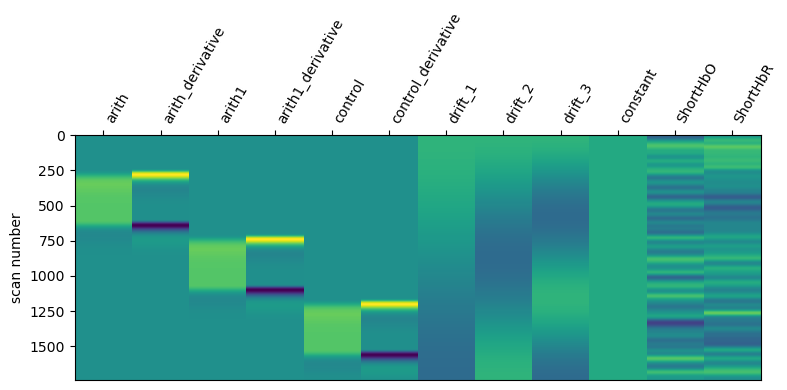

Fitting GLM...
variable          Condition    df           mse       p_value        se  \
408                ShortHbO  12.0  2.020071e-12  1.209704e-14  0.037456   
409                ShortHbR  12.0  2.020071e-12  2.761215e-07  0.220723   
410                   arith  12.0  2.020071e-12  4.259617e-01  0.000005   
411                  arith1  12.0  2.020071e-12  2.750733e-02  0.000005   
412       arith1_derivative  12.0  2.020071e-12  5.348674e-07  0.000021   

variable          t     theta  Source  Detector Chroma  Significant    ch_name  
408       44.079349  1.651052       3         2    hbo         True  S3_D2 hbo  
409      -10.243032 -2.260877       3         2    hbo         True  S3_D2 hbo  
410       -0.824096 -0.000004       3         2    hbo        False  S3_D2 hbo  
411       -2.508025 -0.000013       3         2    hbo         True  S3_D2 hbo  
412       -9.634221 -0.000202       3         2    hbo         True  S3_D2 hbo  
Saved GLM results to: /Users/divijnalge/Library/

In [25]:
# glm_from_snirf.py

from pathlib import Path

import mne
import pandas as pd

from mne.preprocessing.nirs import optical_density, beer_lambert_law
from mne_nirs.channels import get_long_channels
from mne_nirs.experimental_design import make_first_level_design_matrix
from mne_nirs.statistics import run_glm

# -----------------------------
# 0) INPUTS (EDIT THESE)
# -----------------------------
snirf_path = select_snirf_file(INPUT_DIR)
out_csv1 = snirf_path.with_name(snirf_path.stem + "_glm_mne.csv")
out_csv    = Path(out_csv1)


# -----------------------------
# 1) LOAD SNIRF
# -----------------------------
print(f"Loading SNIRF: {snirf_path}")
raw = mne.io.read_raw_snirf(snirf_path, preload=True)
print(raw)  # quick sanity check
print("Channel types:", raw.get_channel_types(unique=True))
print("Onset: ", raw.annotations.onset)
print("Duration: ", raw.annotations.duration)
print("Description: ", raw.annotations.description)

# Typical block length for your task (seconds)
STIM_DUR = raw.annotations.duration[0]   # change to your actual block duration

# -----------------------------
# 2) ENSURE HAEMOGLOBIN DATA
# -----------------------------
ch_types = raw.get_channel_types(unique=True)

if "fnirs_cw_amplitude" in ch_types:
    # Case A: SNIRF still contains intensity → convert to HbO/HbR
    print("Detected intensity data → converting to HbO/HbR")
    raw_od = optical_density(raw)
    raw_haemo = beer_lambert_law(raw_od)
elif any(ct in ("hbo", "hbr") for ct in ch_types):
    # Case B: already haemoglobin (typical for your Homer3 export)
    print("Detected haemoglobin data → using as-is")
    raw_haemo = raw.copy()
else:
    raise RuntimeError(
        "Unexpected channel types. Expected 'fnirs_cw_amplitude' or 'hbo'/'hbr'."
    )

# -----------------------------
# 3) KEEP ONLY LONG CHANNELS
# -----------------------------

from mne.preprocessing.nirs import source_detector_distances

def print_src_det_distances_with_type(raw, short_max=0.01, long_min=0.015, long_max=0.045):
    picks = mne.pick_types(
        raw.info, meg=False, eeg=False, fnirs=True, exclude=[]
    )
    dists_m = source_detector_distances(raw.info, picks=picks)

    print("\nSource-detector distances:")
    for pick, dist_m in zip(picks, dists_m):
        ch_name = raw.ch_names[pick]
        dist_cm = dist_m * 100

        if dist_m < short_max:
            kind = "SHORT"
        elif long_min < dist_m < long_max:
            kind = "LONG"
        else:
            kind = "OTHER"

        print(f"{ch_name:15s}  {dist_m:.5f} m   ({dist_cm:.2f} cm)   {kind}")

print_src_det_distances_with_type(raw_haemo)

def load_prepare_run_single(raw_hb):
    """
    Load one run SNIRF, ensure HbO/HbR, keep long channels, clean annotations.
    NOTE: Replace mlAct_ALL_mne with the mlAct_RUN
    """

    def _drop_bad_annotations(raw: mne.io.BaseRaw) -> mne.io.BaseRaw:
        """Remove boundary/bad annotations so they don't become regressors."""
        ann = raw.annotations
        if ann is None or len(ann) == 0:
            return raw
        keep = [not str(d).upper().startswith("BAD") for d in ann.description]
        raw.set_annotations(ann[keep])
        return raw

    #======================================================================================
    #Uncomment to change arith1 to arith (events arith and arith1 will be treated the same)
    #======================================================================================
    #raw_hb.annotations.rename({"arith1": "arith"}) 

    # mlActAuto_ALL must align with raw_hb.ch_names (same length + same order)

    


    # ======================================================
    # automatic pruning
    # ======================================================
        
    if len(raw_hb.ch_names) != len(mlAct_ALL_mne):
        raise ValueError(
            f"Run {i}: mask length {len(mlActAuto_ALL)} != channels {len(raw_hb.ch_names)}"
        )
    
    # Channels to drop are where mask == 0 / False
    dropped = [ch for ch, keep in zip(raw_hb.ch_names, mlAct_ALL_mne) if not bool(keep)]
    kept    = [ch for ch, keep in zip(raw_hb.ch_names, mlAct_ALL_mne) if bool(keep)]
    
    print(f"Total channels: {len(raw_hb.ch_names)}")
    print(f"Kept channels : {len(kept)}")
    print(f"Dropped channels: {len(dropped)}")
    print("Dropped list:", dropped)
    
    # Apply drop
    raw_hb = raw_hb.copy().drop_channels(dropped)

    # ======================================================
    # manual pruning
    # ======================================================
    raw_hb = apply_manual_pruning(
        raw_hb,
        manual_drop=MANUAL_DROP,
        manual_keep_only=None,
    )
    
    print(f"Channels after manual pruning: {len(raw_hb.ch_names)}")
    print("Remaining channels:", raw_hb.ch_names)

    # Now compute short/long on the cleaned raw
    short_chs = get_short_channels(raw_hb)
    raw_hb  = get_long_channels(raw_hb)

    print("Short channel count:", len(short_chs.ch_names))
    print("Short channels:", short_chs.ch_names)
    print("Long channel count:", len(raw_hb.ch_names))
    print("Long channels:", raw_hb.ch_names)



    raw_hb = _drop_bad_annotations(raw_hb)  # again after transforms (safe)
    return raw_hb, short_chs

# Removes short-separation channels; default 1.5–4.5 cm. 
raw_haemo, short_chs = load_prepare_run_single(raw_haemo)
print("Remaining channels:", len(raw_haemo.ch_names))

# (Optional) extra filter here if you *haven't* prefiltered in Homer3.
# raw_haemo = raw_haemo.filter(0.01, 0.2, verbose=False)

# -----------------------------
# 4) DESIGN MATRIX
# -----------------------------
# Uses raw_haemo.annotations (from SNIRF stim) to build regressors.
# Each unique description becomes a regressor. 

design_matrix = make_first_level_design_matrix(
    raw_haemo,
    drift_model="cosine",
    high_pass=0.01,
    hrf_model="spm + derivative",
    stim_dur=STIM_DUR
    )

design_matrix["ShortHbO"] = np.mean(
    short_chs.copy().pick(picks="hbo").get_data(), axis=0
    )

design_matrix["ShortHbR"] = np.mean(
    short_chs.copy().pick(picks="hbr").get_data(), axis=0
    )

print("Design matrix columns:", list(design_matrix.columns))
print(design_matrix.head())

# If you have nilearn installed, you can visualise the design:
from nilearn.plotting import plot_design_matrix
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(8, 4))
plot_design_matrix(design_matrix, axes=ax)
fig.tight_layout()
plt.show()

# -----------------------------
# 5) RUN GLM
# -----------------------------
# Wrapper around Nilearn's GLM; default AR(1) noise model. 
print("Fitting GLM...")
glm_est = run_glm(raw_haemo, design_matrix)

# glm_est is a RegressionResults object with GLM fits for all channels. 

# -----------------------------
# 6) EXPORT RESULTS
# -----------------------------
# Converts all GLM results to a tidy DataFrame:
# one row per (channel, condition, chroma) with theta, t, p, etc. 
df = glm_est.to_dataframe()
print(df.head())

df.to_csv(out_csv, index=False)
print(f"Saved GLM results to: {out_csv}")


# Plot glm data from csv 

Read MNE-NIRS GLM results saved with RegressionResults.to_dataframe() and generate plots.

Loading GLM results from: /Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne/out_dir/sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb_mne_clean_glm_mne.csv

Columns in file:
['Condition', 'df', 'mse', 'p_value', 'se', 't', 'theta', 'Source', 'Detector', 'Chroma', 'Significant', 'ch_name']

Unique chroma in CSV:
['hbo', 'hbr']

Unique conditions in CSV:
['ShortHbO', 'ShortHbR', 'arith', 'arith1', 'arith1_derivative', 'arith_derivative', 'constant', 'control', 'control_derivative', 'drift_1', 'drift_2', 'drift_3']

Task-like conditions after filtering:
['arith', 'arith1', 'control']

Conditions of interest (used for plots):
['arith', 'arith1', 'control']

Plotting ALL rows (not filtering by p-value).

Number of significant channels (p < 0.050) per condition & chroma:
         Condition Chroma  n_sig_channels
          ShortHbO    hbo              30
          ShortHbO  

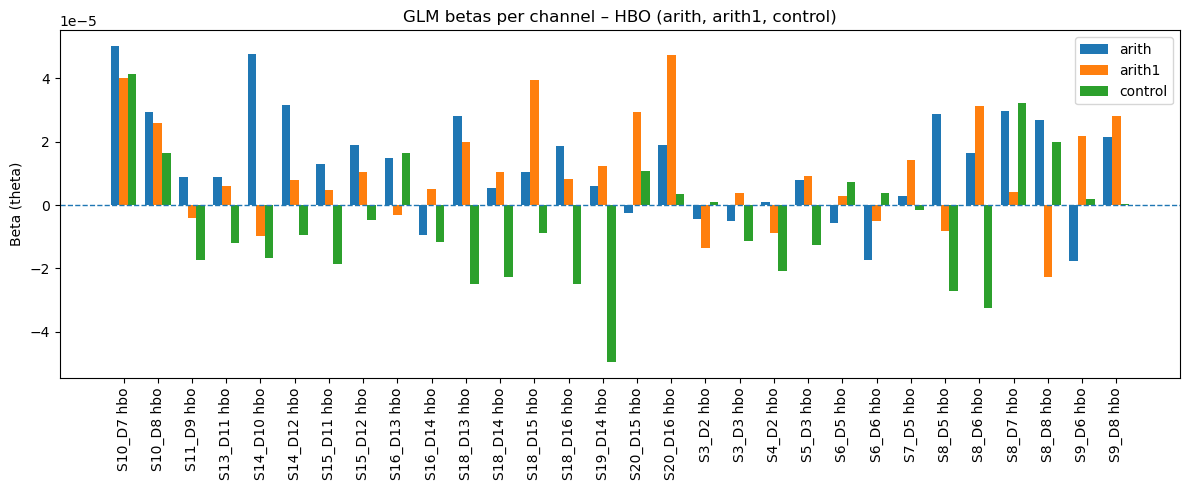

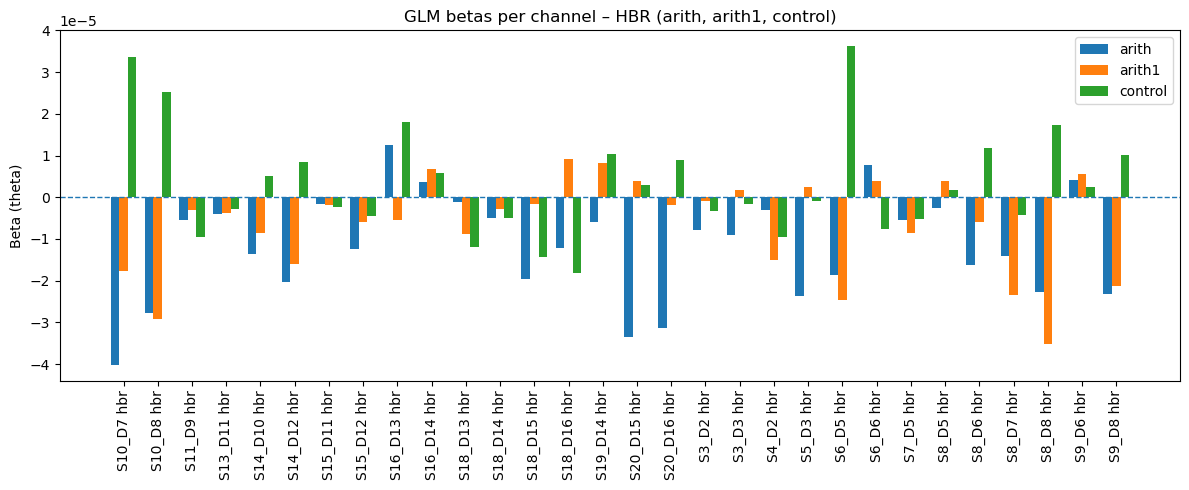


Creating heatmap of HbO betas for detected conditions...


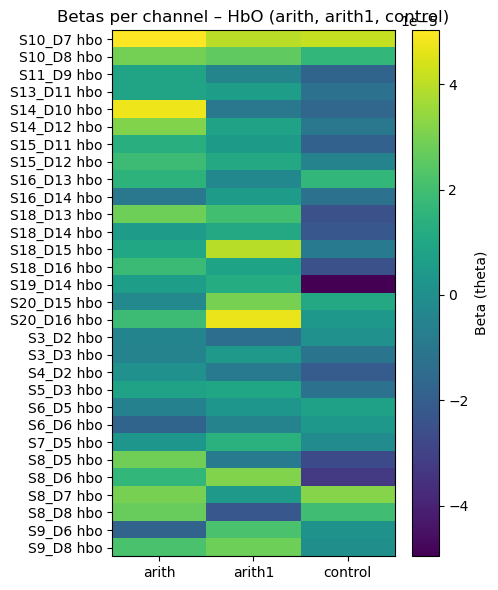


Creating volcano-style scatter for detected conditions...


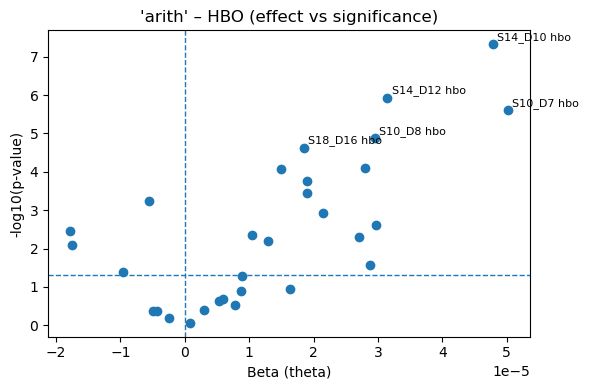

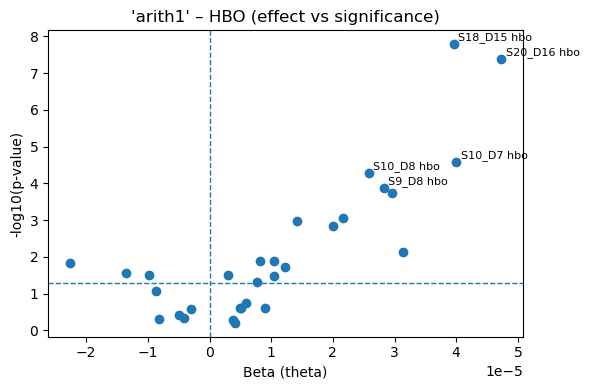

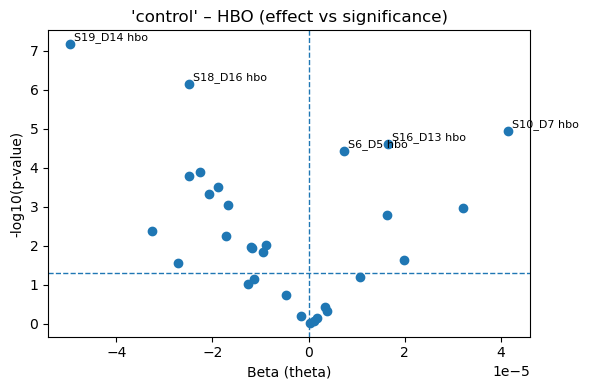

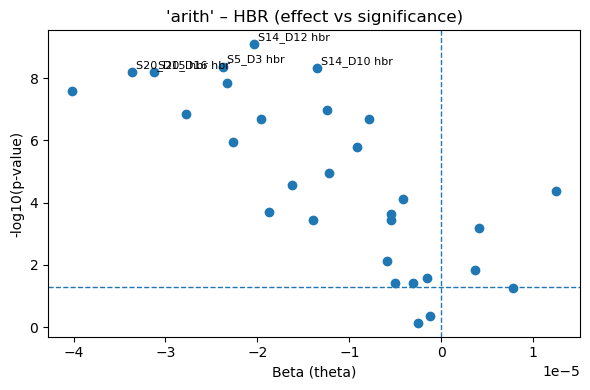

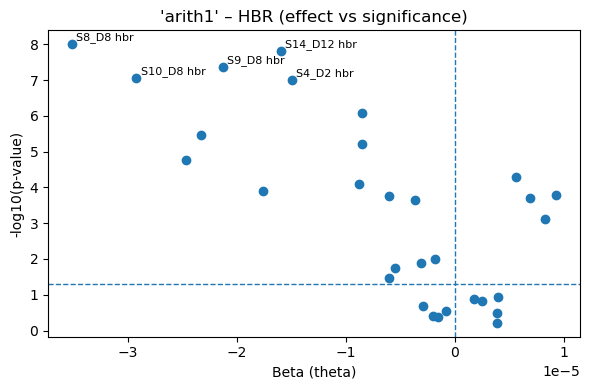

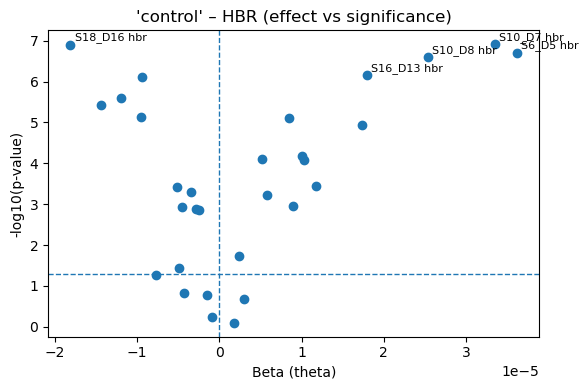


Done. Figures have been displayed.


In [26]:
# Expected CSV columns:
#   Condition, Chroma, ch_name, theta, p_value, ...

from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 0) INPUTS
# -----------------------------
CSV_PATH = Path(out_csv)

ALPHA = 0.05            # p-value threshold
TOP_N_CONDITIONS = 3    # how many conditions to auto-pick (e.g., 3 like arith/arith1/control)
PLOT_ONLY_SIG = False   # if True: plots only significant channels (p<ALPHA); else plots all channels

# Optional manual override:
# conditions_of_interest = ["arith", "arith1", "control"]
conditions_of_interest = None  # set to list to override auto-detection

# -----------------------------
# 1) LOAD DATA
# -----------------------------
print(f"Loading GLM results from: {CSV_PATH}")
df = pd.read_csv(CSV_PATH)

required_cols = {"Condition", "Chroma", "ch_name", "theta", "p_value"}
missing = required_cols.difference(df.columns)
if missing:
    raise RuntimeError(f"CSV is missing columns: {missing}")

df["Condition"] = df["Condition"].astype(str).str.strip()
df["Chroma"] = df["Chroma"].astype(str).str.strip().str.lower()
df["ch_name"] = df["ch_name"].astype(str).str.strip()

print("\nColumns in file:")
print(df.columns.tolist())

print("\nUnique chroma in CSV:")
print(sorted(df["Chroma"].unique().tolist()))

# -----------------------------
# 2) AUTO-DETECT CONDITIONS OF INTEREST
# -----------------------------
def _is_task_condition(name: str) -> bool:
    """
    Heuristics to keep only task regressors / trial types.
    Drops typical nuisance regressors and derivatives.
    Adjust patterns if your naming differs.
    """
    n = name.strip().lower()

    # drop empty/none-ish
    if n == "" or n == "nan":
        return False

    # drop obvious nuisance / non-task
    drop_prefixes = (
        "drift", "constant", "short", "bad", "edge", "boundary"
    )
    if n.startswith(drop_prefixes):
        return False

    # drop derivatives and common HRF extras
    if "derivative" in n or "dispersion" in n:
        return False

    # sometimes these appear as regressors in some pipelines
    if n in {"intercept"}:
        return False

    return True

all_conditions = sorted(df["Condition"].unique().tolist())
task_conditions = [c for c in all_conditions if _is_task_condition(c)]

print("\nUnique conditions in CSV:")
print(all_conditions)

print("\nTask-like conditions after filtering:")
print(task_conditions)

if conditions_of_interest is None:
    if len(task_conditions) == 0:
        raise RuntimeError(
            "Auto-detection found zero task-like conditions. "
            "Set conditions_of_interest manually."
        )

    # rank conditions by coverage (#rows or #unique channels)
    rank = (
        df[df["Condition"].isin(task_conditions)]
          .groupby("Condition")["ch_name"]
          .nunique()
          .sort_values(ascending=False)
    )

    conditions_of_interest = rank.head(TOP_N_CONDITIONS).index.tolist()

print("\nConditions of interest (used for plots):")
print(conditions_of_interest)

# -----------------------------
# 3) (OPTIONAL) FILTER TO SIGNIFICANT ONLY
# -----------------------------
if PLOT_ONLY_SIG:
    df_plot = df[df["p_value"] < ALPHA].copy()
    print(f"\nPlotting ONLY significant rows (p < {ALPHA}).")
else:
    df_plot = df.copy()
    print(f"\nPlotting ALL rows (not filtering by p-value).")

# -----------------------------
# 4) SUMMARY: SIGNIFICANT CHANNELS
# -----------------------------
sig = df[df["p_value"] < ALPHA]
summary = (
    sig.groupby(["Condition", "Chroma"])["ch_name"]
       .nunique()
       .reset_index(name="n_sig_channels")
)
print(f"\nNumber of significant channels (p < {ALPHA:.3f}) per condition & chroma:")
print(summary.to_string(index=False))

# -----------------------------
# Helper
# -----------------------------
def _order_channels(sub_df: pd.DataFrame) -> pd.DataFrame:
    """Sort by channel name and set ch_name as index."""
    return sub_df.sort_values("ch_name").set_index("ch_name")

# -----------------------------
# 5) GROUPED BAR PLOTS: BETAS PER CHANNEL (AUTO CONDITIONS)
# -----------------------------
print("\nCreating grouped bar plots per channel for detected conditions...")

chroma_list = sorted(df_plot["Chroma"].unique())

for chroma in chroma_list:
    df_ch = df_plot[(df_plot["Chroma"] == chroma) & (df_plot["Condition"].isin(conditions_of_interest))]
    if df_ch.empty:
        print(f"  - Skipping chroma '{chroma}': no rows for selected conditions.")
        continue

    # Create one ordered table per condition
    cond_tables = {}
    for cond in conditions_of_interest:
        sub = df_ch[df_ch["Condition"] == cond]
        if sub.empty:
            continue
        cond_tables[cond] = _order_channels(sub)

    # Need at least 2 conditions to make a meaningful grouped plot
    if len(cond_tables) < 2:
        print(f"  - Skipping chroma '{chroma}': found <2 conditions present.")
        continue

    # Align by common channels across all present conditions
    common = None
    for cond, tab in cond_tables.items():
        common = tab.index if common is None else common.intersection(tab.index)

    if common is None or len(common) == 0:
        print(f"  - Skipping chroma '{chroma}': no common channels across conditions.")
        continue

    # Build matrix of betas (rows=channels, cols=conditions)
    common = common.sort_values()
    beta_mat = np.column_stack([cond_tables[cond].loc[common, "theta"].to_numpy()
                               for cond in conditions_of_interest if cond in cond_tables])

    present_conds = [cond for cond in conditions_of_interest if cond in cond_tables]

    x = np.arange(len(common))
    width = min(0.8 / len(present_conds), 0.25)

    fig, ax = plt.subplots(figsize=(12, 5))
    for j, cond in enumerate(present_conds):
        ax.bar(x + (j - (len(present_conds)-1)/2)*width, beta_mat[:, j], width, label=cond)

    ax.axhline(0.0, linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(common, rotation=90)
    ax.set_ylabel("Beta (theta)")
    ax.set_title(f"GLM betas per channel – {chroma.upper()} ({', '.join(present_conds)})")
    ax.legend()
    fig.tight_layout()
    plt.show()

# -----------------------------
# 6) HEATMAP: HbO BETAS FOR DETECTED CONDITIONS
# -----------------------------
print("\nCreating heatmap of HbO betas for detected conditions...")

if "hbo" in df_plot["Chroma"].unique():
    df_hbo = df_plot[(df_plot["Chroma"] == "hbo") & (df_plot["Condition"].isin(conditions_of_interest))]
    if not df_hbo.empty:
        heat = df_hbo.pivot(index="ch_name", columns="Condition", values="theta")

        # Keep columns in the chosen order (only those present)
        cols_present = [c for c in conditions_of_interest if c in heat.columns]
        heat = heat[cols_present].sort_index()

        fig, ax = plt.subplots(figsize=(5, max(4, len(heat) * 0.2)))
        im = ax.imshow(heat.values, aspect="auto")

        ax.set_xticks(np.arange(heat.shape[1]))
        ax.set_xticklabels(heat.columns)
        ax.set_yticks(np.arange(heat.shape[0]))
        ax.set_yticklabels(heat.index)

        ax.set_title(f"Betas per channel – HbO ({', '.join(cols_present)})")
        cbar = fig.colorbar(im, ax=ax)
        cbar.set_label("Beta (theta)")

        fig.tight_layout()
        plt.show()
    else:
        print("No HbO rows for detected conditions found in CSV.")
else:
    print("No HbO data in CSV – skipping heatmap.")

# -----------------------------
# 7) VOLCANO PLOTS: EACH DETECTED CONDITION (BETA vs -log10(p))
# -----------------------------
print("\nCreating volcano-style scatter for detected conditions...")

for chroma in chroma_list:
    for cond in conditions_of_interest:
        df_cond = df_plot[(df_plot["Condition"] == cond) & (df_plot["Chroma"] == chroma)]
        if df_cond.empty:
            continue

        p = df_cond["p_value"].clip(lower=1e-12)
        neg_log_p = -np.log10(p)

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.scatter(df_cond["theta"], neg_log_p)

        ax.axvline(0.0, linestyle="--", linewidth=1)
        ax.axhline(-np.log10(ALPHA), linestyle="--", linewidth=1)

        ax.set_xlabel("Beta (theta)")
        ax.set_ylabel("-log10(p-value)")
        ax.set_title(f"'{cond}' – {chroma.upper()} (effect vs significance)")

        # Label top 5 most significant
        top = df_cond.assign(neg_log_p=neg_log_p).nlargest(5, "neg_log_p")
        for _, row in top.iterrows():
            ax.annotate(
                row["ch_name"],
                (row["theta"], -np.log10(max(row["p_value"], 1e-12))),
                xytext=(3, 3),
                textcoords="offset points",
                fontsize=8,
            )

        fig.tight_layout()
        plt.show()

print("\nDone. Figures have been displayed.")


## Pick best channel based on metrics

1. maximum |t| value
2. minimum p-value
3. maximum theta value

In [32]:
import numpy as np

def pick_best_channel(
    df,
    condition="arith",
    chroma="hbo",
    metric="abs_t",          # "abs_t" | "min_p" | "theta"
    p_max=None,              # e.g. 0.05 to only consider significant
    theta_sign=None,         # "pos" | "neg" | None
    exclude_nuisance=True,   # drop drift/constant/Short/derivative if you want
):
    d = df.copy()

    # filter to condition + chroma
    d = d[(d["Condition"] == condition) & (d["Chroma"] == chroma)]

    # optional: restrict by p-value
    if p_max is not None:
        d = d[d["p_value"] <= p_max]

    # optional: restrict by theta sign
    if theta_sign == "pos":
        d = d[d["theta"] > 0]
    elif theta_sign == "neg":
        d = d[d["theta"] < 0]

    # optional: exclude nuisance-like rows (mainly useful if condition list is broader)
    if exclude_nuisance:
        bad_prefix = ("Short", "drift", "constant")
        d = d[~d["Condition"].str.startswith(bad_prefix)]
        # Usually you DO want derivatives when plotting “condition-only”.
        # If you want to exclude them from selection, uncomment:
        # d = d[~d["Condition"].str.endswith("_derivative")]

    if len(d) == 0:
        raise ValueError("No rows left after filtering. Loosen p_max/theta_sign or check condition/chroma names.")

    # choose best
    if metric == "abs_t":
        idx = d["t"].abs().idxmax()
    elif metric == "min_p":
        idx = d["p_value"].idxmin()
    elif metric == "theta":
        #CHANGED to find highest positive theta value
        idx = d["theta"].idxmax()
    else:
        raise ValueError("metric must be one of: 'abs_t', 'min_p', 'theta'")

    row = d.loc[idx]
    return row["ch_name"], row


df = glm_est.to_dataframe()

# 1) Best by strongest evidence (max |t|)
ch_name, row = pick_best_channel(df, condition="arith", chroma="hbo", metric="abs_t")
print("Best (abs_t):", ch_name, row[["theta","t","p_value"]].to_dict())

# 2) Best by smallest p-value
ch_name, row = pick_best_channel(df, condition="arith", chroma="hbo", metric="min_p")
print("Best (min_p):", ch_name, row[["theta","t","p_value"]].to_dict())

# 3) Best by largest effect size (max theta)
ch_name, row = pick_best_channel(df, condition="arith", chroma="hbo", metric="theta")
print("Best (theta):", ch_name, row[["theta","t","p_value"]].to_dict())

# Optional: only significant + positive HbO
# ch_name, row = pick_best_channel(df, condition="arith", chroma="hbo", metric="abs_t", p_max=0.05, theta_sign="pos")


Best (abs_t): S15_D11 hbo {'theta': -3.08213873083319e-05, 't': -19.49159103493868, 'p_value': 4.880846976918972e-17}
Best (min_p): S15_D11 hbo {'theta': -3.08213873083319e-05, 't': -19.49159103493868, 'p_value': 4.880846976918972e-17}
Best (theta): S8_D7 hbo {'theta': 0.00011028974838164168, 't': 16.87680419967803, 'p_value': 1.5840198073755208e-15}


## Plot the hemodynamic response for different triggers, for a given channel.

All annotation labels:
['arith', 'arith1', 'control']

Auto-picked task triggers (duration>0, not BAD/EDGE/boundary, present in design matrix):
['arith', 'arith1', 'control']
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


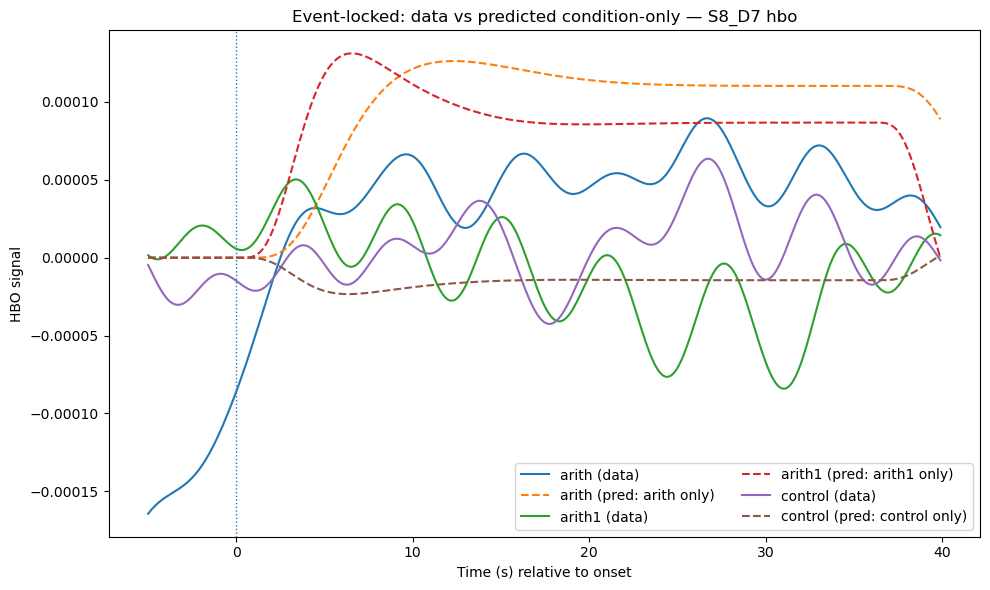

In [33]:
import re
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Helpers
# -----------------------------
def betas_for_channel(df_glm, ch_name):
    """Return beta (theta) indexed by Condition for one channel."""
    sub = df_glm[df_glm["ch_name"] == ch_name].copy()
    if sub.empty:
        raise ValueError(f"Channel not found in GLM dataframe: {ch_name}")
    return sub.set_index("Condition")["theta"]

def predict_from_columns(dm, betas, cols):
    """Compute X[:, cols] @ beta[cols] for a chosen set of regressors."""
    cols = [c for c in cols if (c in dm.columns) and (c in betas.index)]
    if len(cols) == 0:
        return np.zeros(len(dm), dtype=float)
    X = dm[cols].to_numpy()
    b = betas.loc[cols].to_numpy()
    return X @ b

def event_onsets_from_annotations(raw, event_name):
    """Get onset sample indices for a specific annotation description."""
    onsets_sec = [o for o, desc in zip(raw.annotations.onset, raw.annotations.description) if desc == event_name]
    return (np.asarray(onsets_sec) * float(raw.info["sfreq"])).astype(int)

def average_locked(y, onsets_samp, sfreq, tmin=-5.0, tmax=40.0):
    """Average y in a window around each onset."""
    n_pre = int(round(abs(tmin) * sfreq))
    n_post = int(round(tmax * sfreq))
    win_len = n_pre + n_post
    epochs = []
    for o in onsets_samp:
        start, stop = o - n_pre, o + n_post
        if start < 0 or stop > len(y):
            continue
        epochs.append(y[start:stop])
    if not epochs:
        return None, None
    epochs = np.vstack(epochs)
    t = np.linspace(tmin, tmax, win_len, endpoint=False)
    return t, epochs.mean(axis=0)

def list_annotation_triggers(raw):
    """Unique annotation descriptions (strings)."""
    desc = [str(d) for d in raw.annotations.description]
    return sorted(set(desc))

def infer_task_triggers(raw, dm_subject=None):
    """
    Pick "event-like" triggers from annotations automatically:
      - has duration > 0
      - not BAD/EDGE/boundary-ish
      - optional: must exist in dm_subject columns (or its base name exists)
    """
    bad_patterns = ("bad", "edge", "boundary")
    triggers = []
    for onset, dur, desc in zip(raw.annotations.onset, raw.annotations.duration, raw.annotations.description):
        d = str(desc).strip()
        if dur <= 0:
            continue
        low = d.lower()
        if any(p in low for p in bad_patterns):
            continue
        triggers.append(d)

    triggers = sorted(set(triggers))

    if dm_subject is None:
        return triggers

    # keep triggers that show up as design-matrix columns (directly),
    # or whose "base" appears (e.g., dm has "task" and "task_derivative")
    dm_cols = set(map(str, dm_subject.columns))
    keep = []
    for t in triggers:
        if t in dm_cols:
            keep.append(t)
            continue
        if f"{t}_derivative" in dm_cols:
            keep.append(t)
            continue
    return keep

def cond_regressors(dm_cols, cond_name):
    """
    Return all regressors that belong to this condition.
    Default rule: cond itself + any derivative variant.
    Adjust here if your naming differs.
    """
    cols = []
    # exact condition
    if cond_name in dm_cols:
        cols.append(cond_name)

    # common derivative naming patterns
    cand = [
        f"{cond_name}_derivative",
        f"{cond_name}__derivative",
        f"{cond_name}:derivative",
    ]
    cols += [c for c in cand if c in dm_cols]

    # also catch patterns like "cond (something)" if you ever have those
    # (keep conservative: startswith + derivative word)
    for c in dm_cols:
        if c.startswith(cond_name) and ("derivative" in c) and c not in cols:
            cols.append(c)

    return cols

# -----------------------------
# Inputs you set
# -----------------------------
df = glm_est.to_dataframe()
ch_name = str(ch_name)   # set your channel
CHROMA = "hbo"            # "hbo" or "hbr"
tmin, tmax = -5, 40       # arith event-locked window (sec) 
#tmin, tmax = -2, 12.5

sfreq = float(raw_haemo.info["sfreq"])
dm_cols = list(design_matrix.columns)

# -----------------------------
# 1) Auto-detect triggers from your data
# -----------------------------
triggers = infer_task_triggers(raw_haemo, dm_subject=design_matrix)

print("All annotation labels:")
print(list_annotation_triggers(raw_haemo))

print("\nAuto-picked task triggers (duration>0, not BAD/EDGE/boundary, present in design matrix):")
print(triggers)

if len(triggers) == 0:
    raise RuntimeError(
        "No task triggers found. Either your annotations are missing durations, "
        "or their names don't match design matrix columns."
    )

# -----------------------------
# 2) Betas for this channel + measured data
# -----------------------------
df_ch = df[(df["Chroma"].astype(str).str.lower() == CHROMA)].copy()
betas = betas_for_channel(df_ch, ch_name)

y_true = raw_haemo.copy().pick_channels([ch_name]).get_data().ravel()

# -----------------------------
# 3) Build predicted contribution per trigger automatically
# -----------------------------
preds = {}
for cond in triggers:
    cols = cond_regressors(dm_cols, cond)
    preds[cond] = predict_from_columns(design_matrix, betas, cols)

# -----------------------------
# 4) Plot event-locked averages: data vs predicted (condition-only)
# -----------------------------
plt.figure(figsize=(10, 6))

for cond in triggers:
    onsets = event_onsets_from_annotations(raw_haemo, cond)
    if len(onsets) == 0:
        continue

    t, avg_true = average_locked(y_true, onsets, sfreq, tmin=tmin, tmax=tmax)
    _, avg_pred = average_locked(preds[cond], onsets, sfreq, tmin=tmin, tmax=tmax)
    if avg_true is None:
        continue

    plt.plot(t, avg_true, label=f"{cond} (data)")
    plt.plot(t, avg_pred, linestyle="--", label=f"{cond} (pred: {cond} only)")

plt.axvline(0, linestyle=":", linewidth=1)
plt.xlabel("Time (s) relative to onset")
plt.ylabel(f"{CHROMA.upper()} signal")
plt.title(f"Event-locked: data vs predicted condition-only — {ch_name}")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


## GLM from multiple runs
Outputs the glm metrics for each channel to a .csv file

Found runs:
/Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne/out_dir/sub-bndy_ses-tp1_task-arith_run-1_nirs_with_events_preproc_hb_mne_clean.snirf
/Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne/out_dir/sub-bndy_ses-tp1_task-arith_run-2_nirs_with_events_preproc_hb_mne_clean.snirf
/Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne/out_dir/sub-bndy_ses-tp1_task-arith_run-3_nirs_with_events_preproc_hb_mne_clean.snirf
/Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/preprocessed/tp1arith/sub-bndy/preproc_for_mne/out_dir/sub-bndy_ses-tp1_task-arith_run-4_nirs_with_events_preproc_hb_mne_clean.snirf
/Users/divij

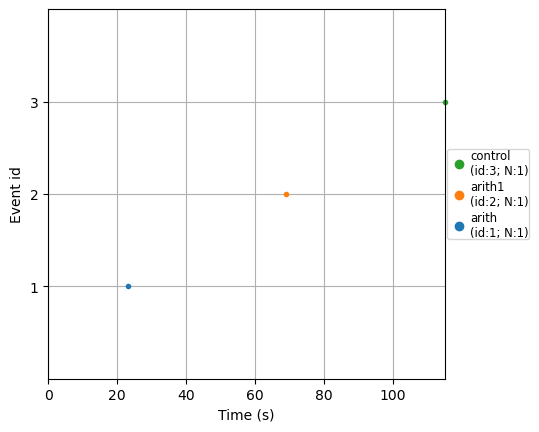

annotations for run 2 :
 <Annotations | 3 segments: arith (1), arith1 (1), control (1)> 


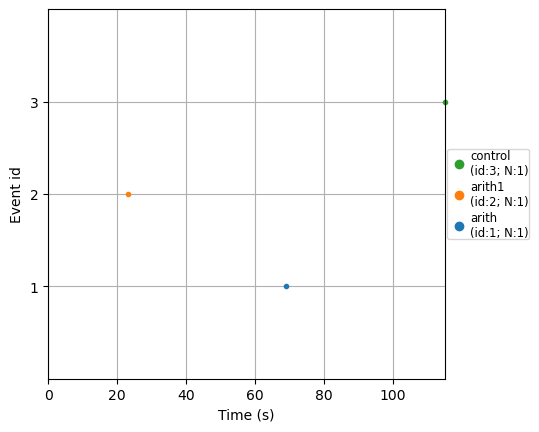

annotations for run 3 :
 <Annotations | 3 segments: arith (1), arith1 (1), control (1)> 


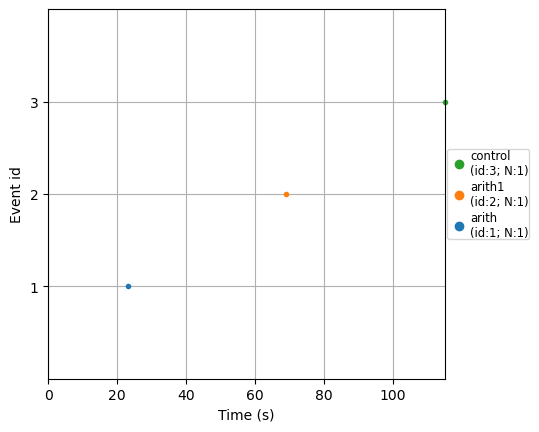

annotations for run 4 :
 <Annotations | 3 segments: arith (1), arith1 (1), control (1)> 


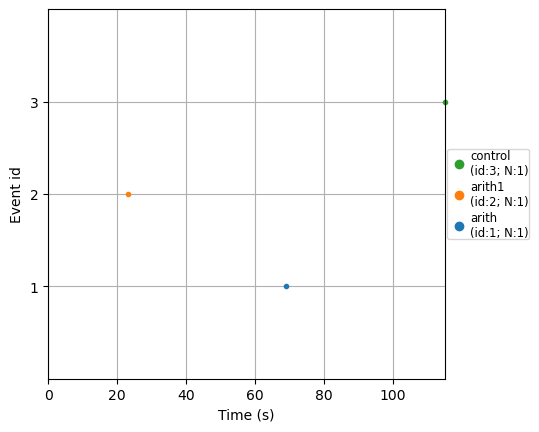

sfreqs : [10.0, 10.0, 10.0, 10.0]

Run 1: adding short channels separately
Short channels in this run: ['S12_D11 hbo', 'S12_D11 hbr', 'S17_D15 hbo', 'S17_D15 hbr']
Run 1: added 4 short-channel regressors
Current DM columns:
['arith', 'arith_derivative', 'arith1', 'arith1_derivative', 'control', 'control_derivative', 'drift_1', 'drift_2', 'drift_3', 'constant', 'short_S12_D11_hbo_run_1', 'short_S12_D11_hbr_run_1', 'short_S17_D15_hbo_run_1', 'short_S17_D15_hbr_run_1']

Run 2: adding short channels separately
Short channels in this run: ['S12_D11 hbo', 'S12_D11 hbr', 'S17_D15 hbo', 'S17_D15 hbr']
Run 2: added 4 short-channel regressors
Current DM columns:
['arith', 'arith_derivative', 'arith1', 'arith1_derivative', 'control', 'control_derivative', 'drift_1', 'drift_2', 'drift_3', 'constant', 'short_S12_D11_hbo_run_2', 'short_S12_D11_hbr_run_2', 'short_S17_D15_hbo_run_2', 'short_S17_D15_hbr_run_2']

Run 3: adding short channels separately
Short channels in this run: ['S12_D11 hbo', 'S12_D1

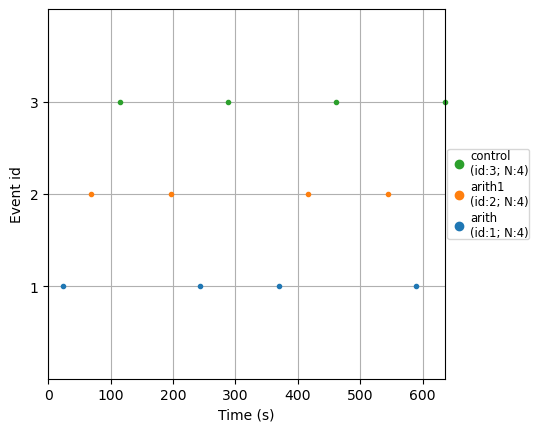

Subject-level design matrix columns:
['arith', 'arith_derivative', 'arith1', 'arith1_derivative', 'control', 'control_derivative', 'drift_1', 'drift_2', 'drift_3', 'constant', 'short_S12_D11_hbo_run_1', 'short_S12_D11_hbr_run_1', 'short_S17_D15_hbo_run_1', 'short_S17_D15_hbr_run_1', 'short_S12_D11_hbo_run_2', 'short_S12_D11_hbr_run_2', 'short_S17_D15_hbo_run_2', 'short_S17_D15_hbr_run_2', 'short_S12_D11_hbo_run_3', 'short_S12_D11_hbr_run_3', 'short_S17_D15_hbo_run_3', 'short_S17_D15_hbr_run_3', 'short_S12_D11_hbo_run_4', 'short_S12_D11_hbr_run_4', 'short_S17_D15_hbo_run_4', 'short_S17_D15_hbr_run_4']
     arith  arith_derivative  arith1  arith1_derivative  control  \
0.0    0.0               0.0     0.0                0.0      0.0   
0.1    0.0               0.0     0.0                0.0      0.0   
0.2    0.0               0.0     0.0                0.0      0.0   
0.3    0.0               0.0     0.0                0.0      0.0   
0.4    0.0               0.0     0.0                

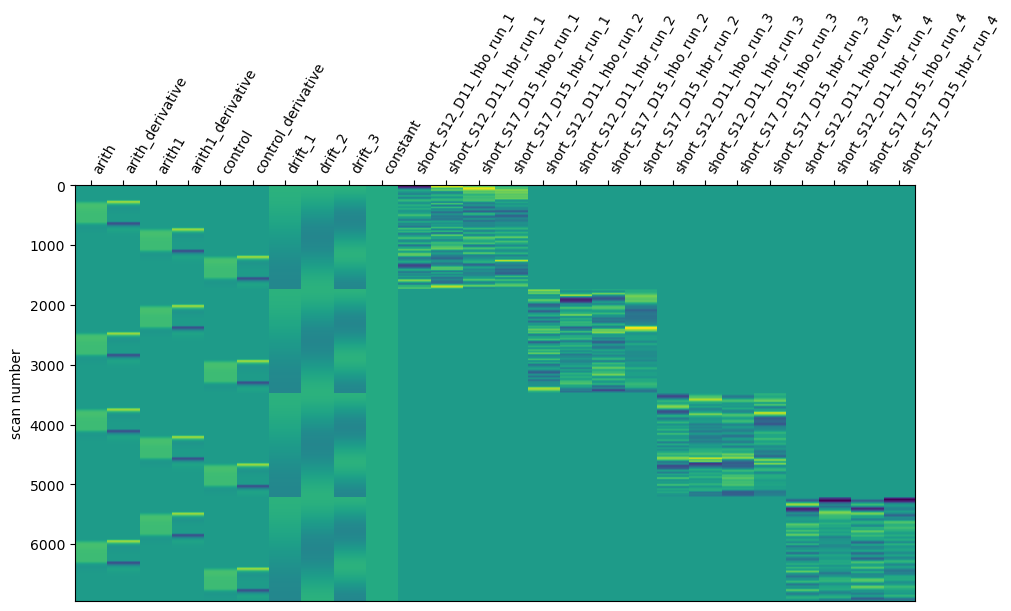

In [29]:

from pathlib import Path
import numpy as np
import pandas as pd
import mne

from mne.preprocessing.nirs import optical_density, beer_lambert_law
from mne_nirs.channels import get_long_channels
from mne_nirs.experimental_design import make_first_level_design_matrix
from mne_nirs.statistics import run_glm
import os

import matplotlib.pyplot as plt
import mne
import numpy as np
from nilearn.plotting import plot_design_matrix

import mne_nirs
from mne_nirs.channels import get_long_channels, get_short_channels, picks_pair_to_idx
from mne_nirs.experimental_design import make_first_level_design_matrix
from mne_nirs.statistics import run_glm


# -----------------------------
# Helpers
# -----------------------------
def _drop_bad_annotations(raw: mne.io.BaseRaw) -> mne.io.BaseRaw:
    """Remove boundary/bad annotations so they don't become regressors."""
    ann = raw.annotations
    if ann is None or len(ann) == 0:
        return raw
    keep = [not str(d).upper().startswith("BAD") for d in ann.description]
    raw.set_annotations(ann[keep])
    return raw


def _infer_stim_dur(raw: mne.io.BaseRaw, fallback: float = 5.0) -> float:
    """Pick a reasonable block duration from annotations."""
    if raw.annotations is None or len(raw.annotations) == 0:
        return fallback
    durs = np.asarray(raw.annotations.duration, dtype=float)
    durs = durs[np.isfinite(durs) & (durs > 0)]
    return float(np.median(durs)) if len(durs) else fallback


def load_prepare_run(snirf_path: Path) -> mne.io.BaseRaw:
    """
    Load one run SNIRF, ensure HbO/HbR, keep long channels, clean annotations.
    """
    raw = mne.io.read_raw_snirf(snirf_path, preload=True)
    raw = _drop_bad_annotations(raw)

    ch_types = raw.get_channel_types(unique=True)

    if "fnirs_cw_amplitude" in ch_types:
        raw_od = optical_density(raw)
        raw_hb = beer_lambert_law(raw_od)
    elif any(ct in ("hbo", "hbr") for ct in ch_types):
        raw_hb = raw.copy()
    else:
        raise RuntimeError(
            f"{snirf_path.name}: Unexpected channel types {ch_types}. "
            "Expected 'fnirs_cw_amplitude' or 'hbo'/'hbr'."
        )

    #======================================================================================
    #Uncomment to change arith1 to arith (events arith and arith1 will be treated the same)
    #======================================================================================
    #raw_hb.annotations.rename({"arith1": "arith"}) 

    

    # ======================================================
    # automatic pruning
    # ======================================================
        
    if len(raw_hb.ch_names) != len(mlAct_ALL_mne):
        raise ValueError(
            f"Run {i}: mask length {len(mlActAuto_ALL)} != channels {len(raw_hb.ch_names)}"
        )
    
    # Channels to drop are where mask == 0 / False
    dropped = [ch for ch, keep in zip(raw_hb.ch_names, mlAct_ALL_mne) if not bool(keep)]
    kept    = [ch for ch, keep in zip(raw_hb.ch_names, mlAct_ALL_mne) if bool(keep)]
    
    print(f"Total channels: {len(raw_hb.ch_names)}")
    print(f"Kept channels : {len(kept)}")
    print(f"Dropped channels: {len(dropped)}")
    print("Dropped list:", dropped)
    
    # Apply drop
    raw_hb = raw_hb.copy().drop_channels(dropped)

    # ======================================================
    # manual pruning
    # ======================================================
    raw_hb = apply_manual_pruning(
        raw_hb,
        manual_drop=MANUAL_DROP,
        manual_keep_only=None,
    )
    
    print(f"Channels after manual pruning: {len(raw_hb.ch_names)}")
    print("Remaining channels:", raw_hb.ch_names)

    # Now compute short/long on the cleaned raw
    short_chs = get_short_channels(raw_hb)
    raw_hb  = get_long_channels(raw_hb)

    print("Short channel count:", len(short_chs.ch_names))
    print("Short channels:", short_chs.ch_names)
    print("Long channel count:", len(raw_hb.ch_names))
    print("Long channels:", raw_hb.ch_names)


    raw_hb = _drop_bad_annotations(raw_hb)  # again after transforms (safe)
    return raw_hb, short_chs

def _safe_short_col_name(ch_name: str, run_idx_1based: int) -> str:
    """
    Convert channel name like 'S2_D3 hbo' into a run-specific DM column name.
    Example:
        short_S2_D3_hbo_run_1
    """
    return f"short_{ch_name.replace(' ', '_')}_run_{run_idx_1based}"

'''
def build_subject_design_matrix_from_run_dms(
    run_dms: list[pd.DataFrame],
    run_n_times: list[int],
    sfreq: float,
) -> pd.DataFrame:

    def split_cols(dm: pd.DataFrame):
        nuisance = [c for c in dm.columns if (c == "constant" or str(c).startswith("drift"))]
        cond = [c for c in dm.columns if c not in nuisance]
        return cond, nuisance

    # Union of all condition columns across runs (shared effects)
    cond_union = []
    for dm in run_dms:
        cond_cols, _ = split_cols(dm)
        for c in cond_cols:
            if c not in cond_union:
                cond_union.append(c)

    offset = 0
    dm_blocks = []

    for i, dm in enumerate(run_dms, start=1):
        dm = dm.copy()

        # Sanity check: DM rows should match data samples for that run
        if dm.shape[0] != run_n_times[i - 1]:
            raise RuntimeError(
                f"Run {i}: design matrix rows ({dm.shape[0]}) != raw.n_times ({run_n_times[i-1]})."
            )

        # Ensure all shared condition columns exist in this run
        for c in cond_union:
            if c not in dm.columns:
                dm[c] = 0.0

        cond_cols, nuisance_cols = split_cols(dm)

        # Rename nuisance columns to be run-specific
        rename_map = {c: f"{c}_run{i}" for c in nuisance_cols}
        dm = dm.rename(columns=rename_map)

        # Keep columns in a consistent order
        dm = dm[cond_union + [rename_map[c] for c in nuisance_cols]]

        # IMPORTANT: use sample index directly (0..n_times-1), then offset
        dm.index = np.arange(run_n_times[i - 1]) + offset
        offset += run_n_times[i - 1]

        dm_blocks.append(dm)

    total_n = int(sum(run_n_times))

    # Stack runs in time; missing columns become NaN -> we fix that
    dm_subject = pd.concat(dm_blocks, axis=0, sort=False).sort_index()

    # Ensure every sample exists (0..total_n-1)
    dm_subject = dm_subject.reindex(np.arange(total_n), fill_value=0.0)

    # convert NaNs (from “columns absent in that run”) into zeros
    dm_subject = dm_subject.fillna(0.0).astype(float)

    # index in seconds (nice for plotting)
    dm_subject.index = dm_subject.index / sfreq

    return dm_subject

'''
def build_subject_design_matrix_from_run_dms(
    run_dms: list[pd.DataFrame],
    run_n_times: list[int],
    sfreq: float,
) -> pd.DataFrame:

    def split_cols(dm: pd.DataFrame):
        nuisance = [
            c for c in dm.columns
            if (
                c == "constant"
                or str(c).startswith("drift")
                or str(c).startswith("short_")
            )
        ]
        cond = [c for c in dm.columns if c not in nuisance]
        return cond, nuisance

    # Shared condition columns across runs
    cond_union = []
    for dm in run_dms:
        cond_cols, _ = split_cols(dm)
        for c in cond_cols:
            if c not in cond_union:
                cond_union.append(c)

    offset = 0
    dm_blocks = []

    for i, dm in enumerate(run_dms, start=1):
        dm = dm.copy()

        if dm.shape[0] != run_n_times[i - 1]:
            raise RuntimeError(
                f"Run {i}: design matrix rows ({dm.shape[0]}) != raw.n_times ({run_n_times[i-1]})."
            )

        # Add missing shared condition columns as zeros
        for c in cond_union:
            if c not in dm.columns:
                dm[c] = 0.0

        cond_cols, nuisance_cols = split_cols(dm)

        # Keep consistent order:
        # shared conditions first, then this run's nuisance columns
        dm = dm[cond_union + nuisance_cols]

        dm.index = np.arange(run_n_times[i - 1]) + offset
        offset += run_n_times[i - 1]

        dm_blocks.append(dm)

    total_n = int(sum(run_n_times))

    dm_subject = pd.concat(dm_blocks, axis=0, sort=False).sort_index()
    dm_subject = dm_subject.reindex(np.arange(total_n), fill_value=0.0)
    dm_subject = dm_subject.fillna(0.0).astype(float)
    dm_subject.index = dm_subject.index / sfreq

    return dm_subject

# -----------------------------
# MAIN
# -----------------------------
# 1) List all run files for this subject

path_str = OUTPUT_DIR
runs_dir = Path(path_str)

run_paths = sorted(runs_dir.glob("*.snirf"))

print("Found runs:")
for p in run_paths:
    print(p)

out_csv = runs_dir / "subject_level_glm_mne.csv"
out_csv.parent.mkdir(exist_ok=True)
print(out_csv)


# 2) Load + prep each run
raw_runs = []; short_chs_runs = [];
for p in run_paths:

    raw_hb, short_chs = load_prepare_run(p)

    short_chs_runs.append(short_chs)
    raw_runs.append(raw_hb)
    

# 3) Make sure channel sets match across runs (use common channels, keep same order)
common = set(raw_runs[0].ch_names)
for r in raw_runs[1:]:
    common &= set(r.ch_names)

if len(common) == 0:
    raise RuntimeError("No common channels across runs after long-channel selection.")

common_order = [ch for ch in raw_runs[0].ch_names if ch in common]
raw_runs = [r.copy().pick_channels(common_order) for r in raw_runs]

# View experiment events
for i in range(len(raw_runs)):

    print("annotations for run {} :\n {} ".format(i+1, raw_runs[i].annotations))
    events, event_dict = mne.events_from_annotations(raw_runs[i], verbose=False)
    mne.viz.plot_events(events, event_id=event_dict, sfreq=raw_runs[i].info["sfreq"])
    

# 4) Check sampling frequency is consistent
sfreqs = [r.info["sfreq"] for r in raw_runs]
if not np.allclose(sfreqs, sfreqs[0]):
    raise RuntimeError(f"Different sampling rates across runs: {sfreqs}. Resample to match first.")
sfreq = float(sfreqs[0])
print("sfreqs :", sfreqs)

'''

# 4b) Force sfreq to match exactly (fix float mismatch)
target_sfreq = 10.0

for k in range(len(raw_runs)):
    sf = float(raw_runs[k].info["sfreq"])
    if sf != target_sfreq:
        print(f"Resampling run {k+1} from {sf} -> {target_sfreq}")
        raw_runs[k].resample(target_sfreq, npad="auto")

# If you also want short-channel raws to stay aligned for regressors:
for k in range(len(short_chs_runs)):
    sf = float(short_chs_runs[k].info["sfreq"])
    if sf != target_sfreq:
        short_chs_runs[k].resample(target_sfreq, npad="auto")

'''


# 5) Build run-level design matrices (one per run)
run_dms = []
run_n_times = []

'''
for i, raw in enumerate(raw_runs):

    stim_dur = _infer_stim_dur(raw, fallback=5.0)

    dm = make_first_level_design_matrix(
    raw,
    drift_model="cosine",
    high_pass=0.01,
    hrf_model="spm + derivative",
    stim_dur=stim_dur
    )

    dm[f"ShortHbO_{i}"] = short_chs_runs[i].copy().pick(picks="hbo").get_data()

    dm[f"ShortHbR_{i}"] = short_chs_runs[i].copy().pick(picks="hbr").get_data()

    
    run_dms.append(dm)
    run_n_times.append(raw.n_times)
'''

for i, raw in enumerate(raw_runs, start=1):

    stim_dur = _infer_stim_dur(raw, fallback=5.0)

    dm = make_first_level_design_matrix(
        raw,
        drift_model="cosine",
        high_pass=0.01,
        hrf_model="spm + derivative",
        stim_dur=stim_dur
    )

    short_run = short_chs_runs[i - 1].copy()

    print(f"\nRun {i}: adding short channels separately")
    print("Short channels in this run:", short_run.ch_names)

    short_data = short_run.get_data()

    for ch_name, ch_data in zip(short_run.ch_names, short_data):
        col_name = _safe_short_col_name(ch_name, i)
        dm[col_name] = ch_data

    print(f"Run {i}: added {len(short_run.ch_names)} short-channel regressors")
    print("Current DM columns:")
    print(list(dm.columns))

    run_dms.append(dm)
    run_n_times.append(raw.n_times)

# -----------------------------
# 5.5) HARD FIX + DEBUG: make sfreq EXACTLY identical in info
# -----------------------------

#===============================================================================================
#===============================================================================================
#===============================================================================================
#===============================================================================================


import numpy as np

def _print_sfreqs(label, raws):
    print(label)
    for i, r in enumerate(raws, 1):
        sf = float(r.info["sfreq"])
        print(f"  run{i}: sfreq = {sf:.18f}")

def _force_exact_sfreq(raw, target_sfreq, *, do_resample_if_needed=True):
    """
    Ensure:
      1) data is resampled if it's truly different
      2) info['sfreq'] becomes EXACTLY float(target_sfreq) for strict concatenation
    """
    raw = raw.copy()

    sf = float(raw.info["sfreq"])

    # If it's genuinely different (not just a float-printing artifact), resample
    if do_resample_if_needed and not np.isclose(sf, target_sfreq, rtol=0, atol=1e-9):
        raw.load_data()
        raw.resample(target_sfreq, npad="auto")

    # Now force exact float equality in the header (strict match required by concatenate)
    with raw.info._unlock():
        raw.info["sfreq"] = float(target_sfreq)

    return raw

# -----------------------------
# Force all runs (and short-ch runs) to EXACT same sfreq
# -----------------------------
_print_sfreqs("Before fixing:", raw_runs)

# pick a clean nominal target (10.0 in your case)
target_sfreq = float(round(np.median([float(r.info["sfreq"]) for r in raw_runs]), 6))

raw_runs = [_force_exact_sfreq(r, target_sfreq) for r in raw_runs]

print("==============================================")
print(raw_runs[0].info['sfreq'])
#print(raw_runs[1].info['sfreq'])
print("==============================================")


short_chs_runs = [_force_exact_sfreq(r, target_sfreq) for r in short_chs_runs]

_print_sfreqs("After fixing:", raw_runs)

# strict verification (like MNE)
sfreqs_exact = [float(r.info["sfreq"]) for r in raw_runs]
assert all(sf == sfreqs_exact[0] for sf in sfreqs_exact), sfreqs_exact

# Now concatenation should work
raw_all = mne.concatenate_raws([r.copy() for r in raw_runs], preload=True)



#===============================================================================================
#===============================================================================================
#===============================================================================================
#===============================================================================================
#===============================================================================================
#===============================================================================================
#===============================================================================================


# 6) Concatenate raws (subject/session time series)
#raw_all = mne.concatenate_raws([r.copy() for r in raw_runs], preload=True)

print("annotations for combined runs :\n {} ".format(raw_all.annotations))
for onset, duration, desc in zip(
    raw_all.annotations.onset,
    raw_all.annotations.duration,
    raw_all.annotations.description
):
    print(onset, duration, desc)
    
events, event_dict = mne.events_from_annotations(raw_all, verbose=False)
mne.viz.plot_events(events, event_id=event_dict, sfreq=raw_all.info["sfreq"])

# 7) Build subject-level design matrix FROM the run-level design matrices
dm_subject = build_subject_design_matrix_from_run_dms(run_dms, run_n_times, sfreq)

#Plot design matrix
fig, ax1 = plt.subplots(figsize=(10, 6), constrained_layout=True)
fig = plot_design_matrix(dm_subject, axes=ax1)

print("Subject-level design matrix columns:")
print(list(dm_subject.columns))
print(dm_subject.head())

n_nans = int(dm_subject.isna().sum().sum())
print("NaNs in design matrix:", n_nans)


# 8) Fit GLM on concatenated data
glm_est = run_glm(raw_all, dm_subject)


# 9) Export
df = glm_est.to_dataframe()
print("df dimensions", df.shape)
df.to_csv(out_csv, index=False)
print(f"Saved subject-level GLM results to: {out_csv}")

In [30]:
print(raw_runs[0].info['sfreq'])
print(raw_runs[1].info['sfreq'])

10.0
10.0


## Pick best channel based on metrics

1. maximum |t| value
2. minimum p-value
3. maximum theta value

In [35]:
import numpy as np

def pick_best_channel(
    df,
    condition="arith",
    chroma="hbo",
    metric="abs_t",          # "abs_t" | "min_p" | "theta"
    p_max=None,              # e.g. 0.05 to only consider significant
    theta_sign=None,         # "pos" | "neg" | None
    exclude_nuisance=True,   # drop drift/constant/Short/derivative if you want
):
    d = df.copy()

    # filter to condition + chroma
    d = d[(d["Condition"] == condition) & (d["Chroma"] == chroma)]

    # optional: restrict by p-value
    if p_max is not None:
        d = d[d["p_value"] <= p_max]

    # optional: restrict by theta sign
    if theta_sign == "pos":
        d = d[d["theta"] > 0]
    elif theta_sign == "neg":
        d = d[d["theta"] < 0]

    # optional: exclude nuisance-like rows (mainly useful if condition list is broader)
    if exclude_nuisance:
        bad_prefix = ("Short", "drift", "constant")
        d = d[~d["Condition"].str.startswith(bad_prefix)]
        # Usually you DO want derivatives when plotting “condition-only”.
        # If you want to exclude them from selection, uncomment:
        # d = d[~d["Condition"].str.endswith("_derivative")]

    if len(d) == 0:
        raise ValueError("No rows left after filtering. Loosen p_max/theta_sign or check condition/chroma names.")

    # choose best
    if metric == "abs_t":
        idx = d["t"].abs().idxmax()
    elif metric == "min_p":
        idx = d["p_value"].idxmin()
    elif metric == "theta":
        #CHANGED to find highest positive theta value
        idx = d["theta"].idxmax()
    else:
        raise ValueError("metric must be one of: 'abs_t', 'min_p', 'theta'")

    row = d.loc[idx]
    return row["ch_name"], row


df = glm_est.to_dataframe()

# 1) Best by strongest evidence (max |t|)
ch_name, row = pick_best_channel(df, condition="arith", chroma="hbo", metric="abs_t")
print("Best (abs_t):", ch_name, row[["theta","t","p_value"]].to_dict())

# 2) Best by smallest p-value
ch_name, row = pick_best_channel(df, condition="arith", chroma="hbo", metric="min_p")
print("Best (min_p):", ch_name, row[["theta","t","p_value"]].to_dict())

# 3) Best by largest effect size (max theta)
ch_name, row = pick_best_channel(df, condition="arith", chroma="hbo", metric="theta")
print("Best (theta):", ch_name, row[["theta","t","p_value"]].to_dict())

# Optional: only significant + positive HbO
# ch_name, row = pick_best_channel(df, condition="arith", chroma="hbo", metric="abs_t", p_max=0.05, theta_sign="pos")


Best (abs_t): S15_D11 hbo {'theta': -3.08213873083319e-05, 't': -19.49159103493868, 'p_value': 4.880846976918972e-17}
Best (min_p): S15_D11 hbo {'theta': -3.08213873083319e-05, 't': -19.49159103493868, 'p_value': 4.880846976918972e-17}
Best (theta): S8_D7 hbo {'theta': 0.00011028974838164168, 't': 16.87680419967803, 'p_value': 1.5840198073755208e-15}


## Plot the hemodynamic response for different triggers, for a given channel.

All annotation labels:
['BAD boundary', 'EDGE boundary', 'arith', 'arith1', 'control']

Auto-picked task triggers (duration>0, not BAD/EDGE/boundary, present in design matrix):
['arith', 'arith1', 'control']
NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).


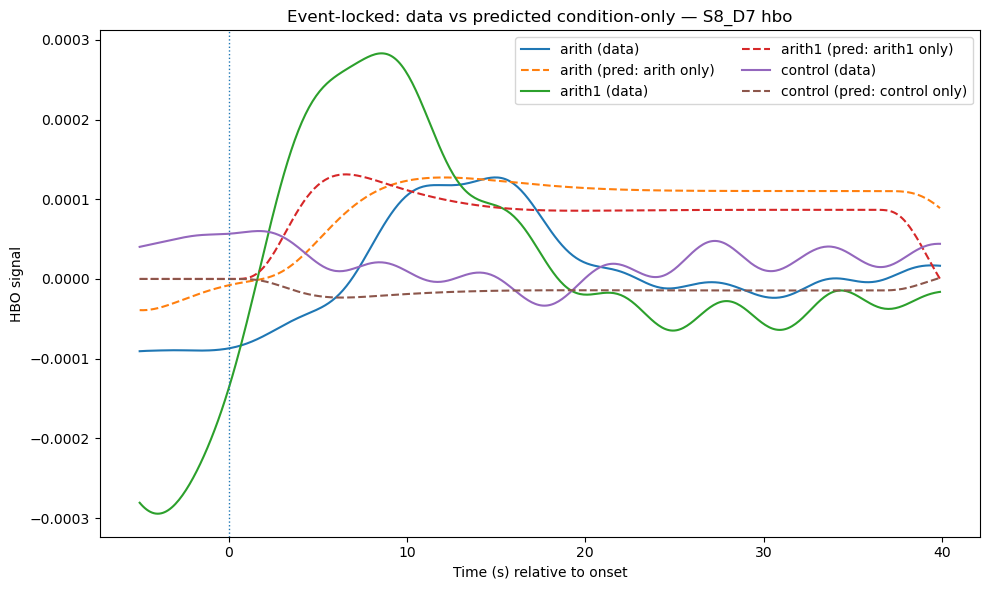

In [36]:
import re
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Helpers
# -----------------------------
def betas_for_channel(df_glm, ch_name):
    """Return beta (theta) indexed by Condition for one channel."""
    sub = df_glm[df_glm["ch_name"] == ch_name].copy()
    if sub.empty:
        raise ValueError(f"Channel not found in GLM dataframe: {ch_name}")
    return sub.set_index("Condition")["theta"]

def predict_from_columns(dm, betas, cols):
    """Compute X[:, cols] @ beta[cols] for a chosen set of regressors."""
    cols = [c for c in cols if (c in dm.columns) and (c in betas.index)]
    if len(cols) == 0:
        return np.zeros(len(dm), dtype=float)
    X = dm[cols].to_numpy()
    b = betas.loc[cols].to_numpy()
    return X @ b

def event_onsets_from_annotations(raw, event_name):
    """Get onset sample indices for a specific annotation description."""
    onsets_sec = [o for o, desc in zip(raw.annotations.onset, raw.annotations.description) if desc == event_name]
    return (np.asarray(onsets_sec) * float(raw.info["sfreq"])).astype(int)

def average_locked(y, onsets_samp, sfreq, tmin=-5.0, tmax=40.0):
    """Average y in a window around each onset."""
    n_pre = int(round(abs(tmin) * sfreq))
    n_post = int(round(tmax * sfreq))
    win_len = n_pre + n_post
    epochs = []
    for o in onsets_samp:
        start, stop = o - n_pre, o + n_post
        if start < 0 or stop > len(y):
            continue
        epochs.append(y[start:stop])
    if not epochs:
        return None, None
    epochs = np.vstack(epochs)
    t = np.linspace(tmin, tmax, win_len, endpoint=False)
    return t, epochs.mean(axis=0)

def list_annotation_triggers(raw):
    """Unique annotation descriptions (strings)."""
    desc = [str(d) for d in raw.annotations.description]
    return sorted(set(desc))

def infer_task_triggers(raw, dm_subject=None):
    """
    Pick "event-like" triggers from annotations automatically:
      - has duration > 0
      - not BAD/EDGE/boundary-ish
      - optional: must exist in dm_subject columns (or its base name exists)
    """
    bad_patterns = ("bad", "edge", "boundary")
    triggers = []
    for onset, dur, desc in zip(raw.annotations.onset, raw.annotations.duration, raw.annotations.description):
        d = str(desc).strip()
        if dur <= 0:
            continue
        low = d.lower()
        if any(p in low for p in bad_patterns):
            continue
        triggers.append(d)

    triggers = sorted(set(triggers))

    if dm_subject is None:
        return triggers

    # keep triggers that show up as design-matrix columns (directly),
    # or whose "base" appears (e.g., dm has "task" and "task_derivative")
    dm_cols = set(map(str, dm_subject.columns))
    keep = []
    for t in triggers:
        if t in dm_cols:
            keep.append(t)
            continue
        if f"{t}_derivative" in dm_cols:
            keep.append(t)
            continue
    return keep

def cond_regressors(dm_cols, cond_name):
    """
    Return all regressors that belong to this condition.
    Default rule: cond itself + any derivative variant.
    Adjust here if your naming differs.
    """
    cols = []
    # exact condition
    if cond_name in dm_cols:
        cols.append(cond_name)

    # common derivative naming patterns
    cand = [
        f"{cond_name}_derivative",
        f"{cond_name}__derivative",
        f"{cond_name}:derivative",
    ]
    cols += [c for c in cand if c in dm_cols]

    # also catch patterns like "cond (something)" if you ever have those
    # (keep conservative: startswith + derivative word)
    for c in dm_cols:
        if c.startswith(cond_name) and ("derivative" in c) and c not in cols:
            cols.append(c)

    return cols

# -----------------------------
# Inputs you set
# -----------------------------
df = glm_est.to_dataframe()
ch_name = str(ch_name)   # set your channel
CHROMA = "hbo"            # "hbo" or "hbr"
tmin, tmax = -5, 40       # arith event-locked window (sec) 
#tmin, tmax = -2, 12.5

sfreq = float(raw_all.info["sfreq"])
dm_cols = list(dm_subject.columns)

# -----------------------------
# 1) Auto-detect triggers from your data
# -----------------------------
triggers = infer_task_triggers(raw_all, dm_subject=dm_subject)

print("All annotation labels:")
print(list_annotation_triggers(raw_all))

print("\nAuto-picked task triggers (duration>0, not BAD/EDGE/boundary, present in design matrix):")
print(triggers)

if len(triggers) == 0:
    raise RuntimeError(
        "No task triggers found. Either your annotations are missing durations, "
        "or their names don't match design matrix columns."
    )

# -----------------------------
# 2) Betas for this channel + measured data
# -----------------------------
df_ch = df[(df["Chroma"].astype(str).str.lower() == CHROMA)].copy()
betas = betas_for_channel(df_ch, ch_name)

y_true = raw_all.copy().pick_channels([ch_name]).get_data().ravel()

# -----------------------------
# 3) Build predicted contribution per trigger automatically
# -----------------------------
preds = {}
for cond in triggers:
    cols = cond_regressors(dm_cols, cond)
    preds[cond] = predict_from_columns(dm_subject, betas, cols)

# -----------------------------
# 4) Plot event-locked averages: data vs predicted (condition-only)
# -----------------------------
plt.figure(figsize=(10, 6))

for cond in triggers:
    onsets = event_onsets_from_annotations(raw_all, cond)
    if len(onsets) == 0:
        continue

    t, avg_true = average_locked(y_true, onsets, sfreq, tmin=tmin, tmax=tmax)
    _, avg_pred = average_locked(preds[cond], onsets, sfreq, tmin=tmin, tmax=tmax)
    if avg_true is None:
        continue

    plt.plot(t, avg_true, label=f"{cond} (data)")
    plt.plot(t, avg_pred, linestyle="--", label=f"{cond} (pred: {cond} only)")

plt.axvline(0, linestyle=":", linewidth=1)
plt.xlabel("Time (s) relative to onset")
plt.ylabel(f"{CHROMA.upper()} signal")
plt.title(f"Event-locked: data vs predicted condition-only — {ch_name}")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


# Surface projection plot

In [38]:
import os
from pathlib import Path
import mne

fsaverage_dir = Path(mne.datasets.fetch_fsaverage(verbose=True))
subjects_dir = fsaverage_dir.parent

os.environ["SUBJECTS_DIR"] = str(subjects_dir)
mne.set_config("SUBJECTS_DIR", str(subjects_dir), set_env=True)

assert (subjects_dir / "fsaverage").exists(), "fsaverage missing in SUBJECTS_DIR"


import re
import numpy as np
import pandas as pd
import mne
from mne_nirs.visualisation import plot_glm_surface_projection

# -----------------------------
# SETTINGS
# -----------------------------
CSV_PATH  = "/Users/divijnalge/Library/CloudStorage/OneDrive-NanyangTechnologicalUniversity/ntu/Brain Norm/Brain_Norm_Files/fNIRS preproc/BN_KG/ses-tp1dig/bnkg_20250626_MNI.csv"
CONDITION = "arith"   # "arith" / "arith1" / "control"/ "ctrl" / "incorrect" / "wm"/ "add" /"sub"
CHROMA    = "hbo"     # "hbo" / "hbr"

DISTANCE  = 0.03
MODE      = "weighted"
VIEW      = "dorsal"
SURFACE   = "pial"

# -----------------------------
# Helpers
# -----------------------------
def _to_meters(xyz: np.ndarray) -> np.ndarray:
    """Convert mm->m if values look like mm."""
    xyz = np.asarray(xyz, float)
    # if median coordinate magnitude > 1, it's almost surely mm
    if np.median(np.abs(xyz)) > 1.0:
        return xyz / 1000.0
    return xyz

def parse_optode_rows(csv_df: pd.DataFrame):
    """
    Extract optode positions from CSV where first column is like Tx12 or Rx7.
    Returns dict: {"S1": [x,y,z], ..., "D1": [x,y,z], ...}
    """
    optodes = {}

    # We will scan every row and look for:
    #   col0 like "Tx12" or "Rx7"
    #   and 3 numeric coords somewhere in the row (usually next 3 cols)
    for i in range(len(csv_df)):
        label = str(csv_df.iloc[i, 0]).strip()
        m = re.match(r"^(Tx|Rx)\s*(\d+)$", label, flags=re.IGNORECASE)
        if not m:
            continue

        kind = m.group(1).lower()   # tx / rx
        num  = int(m.group(2))

        # Try to pull x,y,z from cols 1,2,3 (common layout)
        row = csv_df.iloc[i, :].to_list()
        # collect numeric values from the row (excluding the label)
        nums = []
        for v in row[1:]:
            try:
                if pd.isna(v):
                    continue
                nums.append(float(v))
            except Exception:
                continue

        if len(nums) < 3:
            continue

        xyz = _to_meters(np.array(nums[:3], float))

        # Map Tx -> S (source), Rx -> D (detector)
        key = f"S{num}" if kind == "tx" else f"D{num}"
        optodes[key] = xyz

    if len(optodes) == 0:
        raise RuntimeError("No optode rows like Tx# / Rx# were found in the CSV.")
    return optodes

def build_mne_theta_df(glm_est, condition: str, chroma: str) -> pd.DataFrame:
    """
    Extract theta for one condition+chroma, return dataframe with ['ch_name','theta'].
    theta is scaled to micro-units for readability.
    """
    df = glm_est.to_dataframe(order=glm_est.ch_names)
    out = df.query("Condition == @condition and Chroma == @chroma").copy()
    if out.empty:
        raise RuntimeError(f"No rows found for Condition='{condition}', Chroma='{chroma}'")
    out["theta"] = out["theta"] * 1e6
    return out[["ch_name", "theta"]].reset_index(drop=True)

# -----------------------------
# 1) Read CSV and build optode montage (S*/D* in 3D)
# -----------------------------
csv = pd.read_csv(CSV_PATH)
optode_3d = parse_optode_rows(csv)

# Make montage (coord_frame="head" is accepted by MNE for montage;
# if these are truly MNI coords, this is a “visual coordinate frame” for plotting)
mont3d = mne.channels.make_dig_montage(ch_pos=optode_3d, coord_frame="head")

# -----------------------------
# 2) Attach montage to FULL fNIRS info (must include BOTH hbo+hbr)
# -----------------------------
# Important: use glm_est.info (it contains HbO+HbR, so fNIRS validation passes)
info3d_full = glm_est.info.copy()
info3d_full.set_montage(mont3d, on_missing="ignore")

# -----------------------------
# 3) Build theta dataframe for chosen condition/chroma
# -----------------------------
theta_df = build_mne_theta_df(glm_est, CONDITION, CHROMA)

# -----------------------------
# 4) Make info + dataframe match EXACTLY (strict requirement)
#    plot_glm_surface_projection checks: info.ch_names == df['ch_name']
# -----------------------------
# Keep only channels of chosen chroma, in the same order as info
chroma_names = [ch for ch in info3d_full.ch_names if ch.endswith(f" {CHROMA}")]

# Restrict dataframe to those channels, reorder to match info
theta_df = theta_df.set_index("ch_name").loc[chroma_names].reset_index()

# Create an Info that contains ONLY those channels (so lists match exactly)
sel = mne.pick_channels(info3d_full.ch_names, include=chroma_names)
info3d = mne.pick_info(info3d_full, sel, copy=True)

# -----------------------------
# 5) Plot
# -----------------------------
plot_glm_surface_projection(
    info3d,
    theta_df,
    picks=CHROMA,      # keeps the function happy; channels are only CHROMA anyway
    value="theta",
    mode=MODE,
    distance=DISTANCE,
    surface=SURFACE,
    hemi="both",
    view=VIEW,
    colorbar=True,
)
